# **Diplomado IA: Inteligencia Artificial**.
## Práctico 25 - Repaso Aplicado: Recomendación usando texto e Imágenes
---
---

**Profesores:**
- Julio Hurtado
- Felipe del Río


---
---


In [1]:
Nombre_alumno = "" #@param {type:"string"}


# Agenda

## Práctico 25 - Repaso Aplicado: Recomendación usando texto e Imágenes

<!-- Agenda:
 * Problema
 * Preparación
 * Entrenamiento
 * Recomendación -->

Problema

Preparación

> Datos

> Instalación de librerias

Entrenamiento

> Dataset

> Funciones de Entrenamiento

> Funciones para mostrar resultados

> Modelo

> Entrenamiento

Recomendación

> Obtención de Descriptores

> Encontrar similares

> Recomendación

> Metricas de Comparación


# Objetivo del Laboratorio

Una parte importante para consolidar nuevos conocimientos es ponerlos en práctica. Después de algunas clases donde hemos visto varios métodos y algoritmos diferentes es bueno tomar una pausa para poder aplicar estos conocimientos.

En este laboratorio los aplicaremos a un ejemplo más real que los que hemos visto en laboratorios anteriores. El objetivo es corroborar el entendimiento de los conceptos claves, y que después podremos ser capaces de aplicarlos en diferentes problemas que nos podemos encontrar en la vida real.


## Problema

En este laboratorio aplicaremos los conocimientos vistos en las clases anteriores para entrenar un modelo que pueda recomendar contenido a un usuario de una red social, en base a sus interacciones pasadas.

En esta red social, una interacción está conformada por una imagen y un comentario, escrito por un usuario. El objetivo es generar una reacción en los usuarios, por lo que debemos recomendar o mostrarle imágenes de otros usuarios que tienen imágenes con textos similares. Por esta razón, tenemos que tener acceso tanto a las imágenes como al texto escrito por los usuarios para poder encontrar recomendaciones que causen un accionar en el usuario.


## Disclaimer

Existen muchas formas de resolver este problema. El objetivo de este laboratorio no es encontrar la mejor forma de resolver el problema, sino que aprender a plantear un problema real, viendo alternativas y complejidades que puedan ir apareciendo.





# Preparación
## Datos

Los datos son una de las partes más importantes al momento de entrenar modelos de aprendizaje. Si los datos no representan el problema que queremos resolver es muy difícil que nuestro modelo pueda encontrar una solución adecuada. De ahí viene la famosa expresión **"garbage in, garbage out"**.

En esta oportunidad utilizaremos un dataset abierto creado a partir de la red social **Pinterest**. Este dataset nos entrega imágenes y un comentario creado por un usuario. Por razones de *copyright* no tenemos acceso a las imágenes mismas, ya que esto trasgredería los términos y condiciones de esta red social. Para compartir las imagenes, esta base de datos comparte los descriptores de estas, encontrados con un modelo pre-entrenados sobre Imagenet.

Cada elemento de nuestro dataset está conformado por un par imagen-texto asociado a un usuario. Dado esto, definiremos como nuestra tarea, clasificar a qué usuario pertenece cada par imagen-texto del dataset.



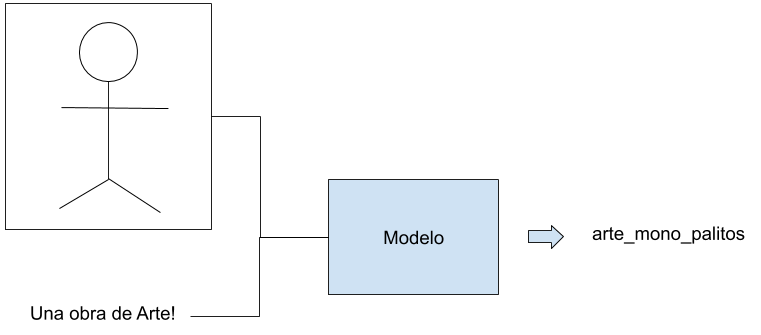

Podemos ver el modelo dividido de dos formas.

1.   Agrupar usuarios dependiendo de sus gustos
2.   Agrupar gustos dependiendo de los usuarios

Queremos que usuarios con gustos similares esten cercanos en el plano, y tambien que grupo de imagenes-texto similares entre ellos tambien esten cercanos.


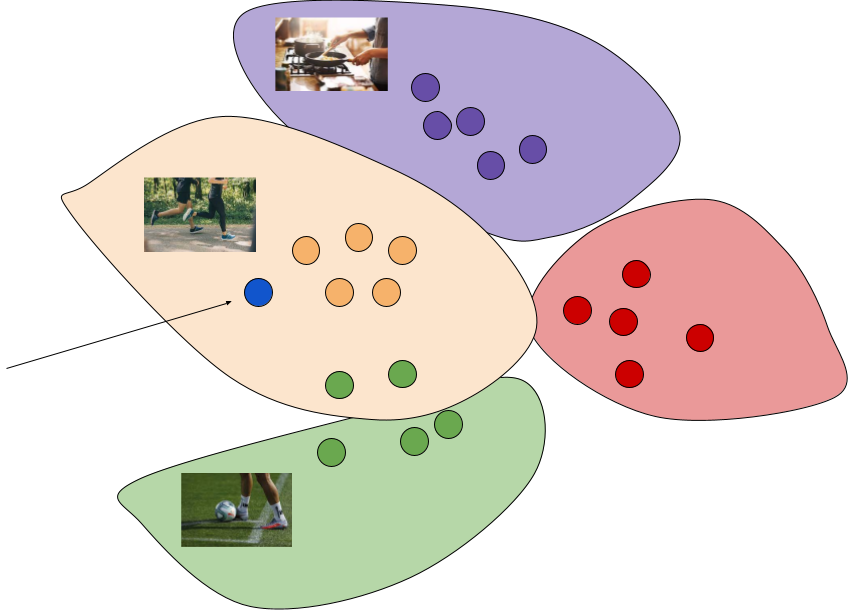

Para poder comenzar, lo primero que debemos hacer es descargar y descomprimir los archivos utilizando los siguientes comandos:

In [2]:
!pip3 install -q --upgrade gdown

In [3]:
!gdown --no-cookies 16qaJyW-eE5Ha0ynAS9unolLageB-yiFI

Downloading...
From (original): https://drive.google.com/uc?id=16qaJyW-eE5Ha0ynAS9unolLageB-yiFI
From (redirected): https://drive.google.com/uc?id=16qaJyW-eE5Ha0ynAS9unolLageB-yiFI&confirm=t&uuid=177d8682-4166-44dd-9bb2-2687359659e8
To: /content/fs4k2zc5j5-3.zip
100% 2.16G/2.16G [00:30<00:00, 71.6MB/s]


In [4]:
!yes | unzip fs4k2zc5j5-3.zip

Archive:  fs4k2zc5j5-3.zip
  inflating: text_train.txt          
  inflating: text_test.txt           
  inflating: imag_val.txt            
  inflating: val_test_users.txt      
  inflating: images.rar              
  inflating: imag_train.txt          
  inflating: text_val.txt            
  inflating: train_users.txt         
  inflating: imag_test.txt           


In [5]:
!mv imag_train.txt imag_train2.txt
!gdown 1Udr59p9vqbUrou2XBx1Dc96v0JcdGzPw

Downloading...
From (original): https://drive.google.com/uc?id=1Udr59p9vqbUrou2XBx1Dc96v0JcdGzPw
From (redirected): https://drive.google.com/uc?id=1Udr59p9vqbUrou2XBx1Dc96v0JcdGzPw&confirm=t&uuid=8ae514e4-5a59-4d9f-8072-8e9db0154a6a
To: /content/imag_train.txt
100% 1.70G/1.70G [00:22<00:00, 75.1MB/s]


Podemos verificar que tenemos todos los datos en nuestro Colab es revisar el navegador de archivos que se encuentra en la izquierda de nuestro navegador.

## Actividad 1

1- Asuma el contexto actual, usted trabaja en una empresa que tiene una red social muy similar a Facebook y quiere recomendar contenido a los usuarios. Responda las siguientes preguntas:

- ¿Qué información recolectaría para poder entrenar su modelo?

In [6]:
R = '' #@param {type:"string"}


- ¿Cómo usaría la información recolectada?

In [7]:
R = '' #@param {type:"string"}

- ¿Existe información externa (que no puede ser recolectada por su empresa) que pueda ser útil para mejorar el rendimiento del modelo? Si su respuesta es afirmativa, de un ejemplo.

In [8]:
R = "" #@param ["", "Si", "No"]
Ejemplo = '' #@param {type:"string"}

## Instalación de librerías

Al igual que en la clase de finetuning, utilizaremos la librería `transformers` que nos facilita la utilización de modelos de texto como Bert, ademas de tokenizadores correspondientes.





In [9]:
!pip install -q transformers==3.5.1
!pip install torch==1.6.0+cu101 torchvision==0.7.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 8.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 45.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==1.6.0+cu101 (from versions: 2.2.0, 2.2.0+cpu, 2.2.0+cpu.cxx11.abi, 2.2.0+cu118,

# Entrenamiento

In [10]:
import numpy as np
import pandas as pd
import os
from random import sample

import torch
from torch.utils.data import Dataset, DataLoader

import transformers
from transformers import BertTokenizer, BertModel
from transformers import PretrainedConfig

from tqdm.auto import tqdm

## Dataset

Creamos la clase `ContentRecommender` y su objetivo es cargar los datos y entregarlos de tal forma que sea aceptado por la clase `DataLoader` de PyTorch.

In [11]:
class ContentRecommender(Dataset):
    def __init__(self, root_dir, data_set='train', num_classes=-1, sub_classes=None, tokenizer=None, transform=None, amount_triplet=3):
        if data_set == 'train':
            self.img_data = pd.read_csv(os.path.join(root_dir,'./imag_train.txt'), header=None).values
            self.txt_data = self.read_file_text(os.path.join(root_dir,'./text_train.txt'))
            self.targets = self.read_file_id(os.path.join(root_dir,'./train_users.txt'))
        elif data_set == 'val':
            self.img_data = pd.read_csv(os.path.join(root_dir,'./imag_val.txt'), header=None).values
            self.txt_data = self.read_file_text(os.path.join(root_dir,'./text_val.txt'))
            self.targets = self.read_file_id(os.path.join(root_dir,'./val_test_users.txt'))
        elif data_set == 'test':
            self.img_data = pd.read_csv(os.path.join(root_dir,'./imag_test.txt'), header=None).values
            self.txt_data = self.read_file_text(os.path.join(root_dir,'./text_test.txt'))
            self.targets = self.read_file_id(os.path.join(root_dir,'./val_test_users.txt'))
        else:
            raise('data_Set must be some of [train, val, test]')

        self.img_data = self.img_data.squeeze()
        self.transform = transform
        self.tokenizer = tokenizer
        self.amount_triplet = amount_triplet

        self.sub_classes = None
        if num_classes != -1 or sub_classes:
            self.sub_set(num_classes, sub_classes)

        self.size_dataset()

    def sub_set(self, num_classes, sub_classes):
        if sub_classes is None:
            sample_cls = sample(list(set(self.targets)), num_classes)
        else:
            sample_cls = sub_classes

        d_img = []
        d_txt = []
        t = []
        for i, cls in enumerate(sample_cls):
            sample_data = (torch.tensor(self.targets) == cls).nonzero().squeeze().numpy()

            d_img.extend(self.img_data[sample_data])
            d_txt.extend([self.txt_data[elem] for elem in sample_data.tolist()])
            t.extend([int(i)]*len(sample_data))

        self.sub_classes = sample_cls
        self.img_data = torch.tensor(d_img)
        self.txt_data = d_txt
        self.targets = t

    def read_file_id(self, name_file):
        data = []
        with open(name_file) as f:
            for line in f:
                data.append(int(line.strip()))
        return data

    def read_file_text(self, name_file):
        data = []
        with open(name_file) as f:
            for line in f:
                data.append(line.strip())
        return data

    def __len__(self):
        return len(self.txt_data)

    def __getitem__(self, idx):
        comment_text = str(self.txt_data[idx])
        comment_text = " ".join(comment_text.split())

        inputs_text = self.tokenizer(
                    comment_text,
                    None,
                    add_special_tokens=True,
                    max_length=100,
                    padding='max_length',
                    return_token_type_ids=True,
                    truncation=True,
                )

        return {
            'text_ids': torch.tensor(inputs_text['input_ids'], dtype=torch.long),
            'text_mask': torch.tensor(inputs_text['attention_mask'], dtype=torch.long),
            'text_token_type_ids': torch.tensor(inputs_text['token_type_ids'], dtype=torch.long),
            'targets': torch.tensor(self.targets[idx], dtype=torch.float),
            'img_data': self.img_data[idx],
            'idx_data': idx
            }

    def size_dataset(self):
        print('We have {} Image with {} features with {} texts. \
                The amount of different users is {}'.format(self.img_data.shape[0],
                                                            self.img_data.shape[1],
                                                            len(self.txt_data),
                                                            len(set(self.targets))))

Debido al tamaño del dataset y las limitaciones de Colab, vamos a utilizar solo un porcentaje del dataset total. Para esto, vamos a seleccionar solo los elementos de una cantidad de clases *num_classes*.

Esto nos permite dos cosas:

1.   Poder entrenar con menos datos nuestro modelo, lo cual nos permite poder entrenar en una cantidad de tiempo razonable.
2.   Poder tener un clasificador de usuarios.

In [12]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
num_classes = 10

trainset = ContentRecommender('./', 'train', num_classes=num_classes, tokenizer=tokenizer)
testset = ContentRecommender('./', 'test', sub_classes=trainset.sub_classes, tokenizer=tokenizer)

batch_size = 64
pin_memory = True if torch.cuda.is_available() else False
loader_kwargs = {'pin_memory': pin_memory, 'num_workers': 2}
loaders = {
    'train': DataLoader(trainset, batch_size=batch_size, shuffle=True, **loader_kwargs),
    'test': DataLoader(testset, batch_size=batch_size, shuffle=False, **loader_kwargs),
    'val': DataLoader(testset, batch_size=batch_size, shuffle=False, **loader_kwargs),
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/tmp/ipykernel_1151/370497844.py:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.img_data = torch.tensor(d_img)


We have 4000 Image with 4096 features with 4000 texts.                 The amount of different users is 10
We have 1000 Image with 4096 features with 1000 texts.                 The amount of different users is 10


**Estructura de AlexNet:**

<figure>
<center>
<img src='https://www.mdpi.com/remotesensing/remotesensing-09-00848/article_deploy/html/images/remotesensing-09-00848-g001.png' height="250" />
<figcaption>Modelo Alexnet</figcaption>
</center>

</figure>

In [13]:
idx = torch.randint(0, len(trainset.targets), (1,1)).item()
print("Un ejemplo del dataset:")
print(trainset.txt_data[idx])
print(trainset.img_data[idx])
print(trainset.targets[idx])

idxs_user = list((torch.tensor(trainset.targets) == trainset.targets[idx]).nonzero())
for id in idxs_user[:5]:
    print(trainset.txt_data[id])

Un ejemplo del dataset:
easily and securely carry your cell phone with this swivel belt clip face in holster custom to fit your phone perfectly plastic pager style holds your phone securely unique design combines holster case and belt clip functions together compatible with motorola i
tensor([-0.6653, -4.8454, -3.6066,  ..., -3.7926, -8.5336,  2.0423],
       dtype=torch.float64)
0
diamond stud earrings are a timeless gift for any occasion this pair of round cut diamonds sits in a secure sterling silver prong setting this accessory allows for endless wear and can be dressed up or down
keep your shoes organized with this tier multipurpose utility shoe rack the frame is constructed using durable steel iron while the shelf itself is layered with composite resin wood each shelf is able to hold up to three full size pairs of shoes as an available option you can also stack two units together forming a complete shelf unit you can also expand horizontally by bridging the shelves to opposing fr

## Funciones de Entrenamiento

Crearemos varias funciones que nos ayudarán con el entrenamiento de modelo. Les recomendamos que traten de entender cada una de estas funciones pues podrán reforzar conocimientos que ya han aprendido en el diplomado hasta ahora.

In [14]:
def run_epoch(phase, model, loader, criterion, optimizer=None):
    n_batches = len(loader)
    if phase == 'train':
        model.train()
    elif phase == 'val' or 'test':
        model.eval()

    cum_loss = 0.0
    cum_acc = 0.0
    for n_batch, data in enumerate(loader, start=1):
        if phase == 'train': # Limpiamos los gradientes solo al entrenar
            optimizer.zero_grad()

        ids = data['text_ids'].to(device, dtype=torch.long)
        mask = data['text_mask'].to(device, dtype=torch.long)
        token_type_ids = data['text_token_type_ids'].to(device, dtype=torch.long)
        img = data['img_data'].to(device, dtype=torch.float)
        targets = data['targets'].to(device, dtype=torch.long)

        result = model(ids, mask, token_type_ids, img) # Aquí se ejecuta nuestro modelo

        loss = criterion(result, targets) # Cálculamos la pérdida
        cum_loss += loss.item()
        _, preds = torch.max(result.data, 1)

        # accuracy = calculate_metrics(targets, preds)
        cum_acc += torch.sum(preds == targets.data)
        if phase == 'train':
            loss.backward() # Hacemos backpropagation solo en train
            optimizer.step() # Actualizamos parámetros solo en train

        current_cum_loss = cum_loss / n_batch
        current_cum_acc = 100 * cum_acc / (n_batch * batch_size)

        print(f'\r{phase.upper()}-Batch {n_batch}/{n_batches} '
              f'Loss: {current_cum_loss:.4f} '
              f'Acc: {current_cum_acc:.2f}% ', end='')

    epoch_loss = float(cum_loss / n_batch)
    epoch_acc = float(100 * cum_acc / (n_batch * batch_size))

    return epoch_loss, epoch_acc

def run_training(model, loaders, optimizer, criterion, n_epochs, scheduler):
    phases = ['train', 'val']
    history = {
        'train': {'loss': [], 'acc': []},
        'val': {'loss': [], 'acc': []}
    }

    print(f"Validating model before training")
    with torch.no_grad():
        val_loss, val_acc = run_epoch('val', model, loaders['val'], criterion)
    print()

    history['val']['loss'].append(val_loss)
    history['val']['acc'].append(val_acc)
    for epoch in range(1, n_epochs + 1):
        print(f"Epoch N°{epoch}")
        for phase in phases:
            epoch_loss, epoch_acc = run_epoch(phase, model, loaders[phase], criterion, optimizer=optimizer)
            # Registramos las pérdidas y accuracy por época, por fase
            history[phase]['loss'].append(epoch_loss)
            history[phase]['acc'].append(epoch_acc)
            print("")

        scheduler.step(history['val']['loss'][-1])

    return history

## Funciones para mostrar resultados

Definamos también algunas funciones que nos ayudarán a visualizar el entrenamiento y sus resultados de mejor forma.

In [15]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sklearn.metrics

def graph_metrics(metricas_test, metricas_train, title=''):
    fig, ax = plt.subplots()
    # plt.style.use('seaborn-white')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.3f'))
    plt.plot(range(1, int(len(metricas_train) + 1)), metricas_train, marker='o')
    plt.plot(range(int(len(metricas_test))), metricas_test, marker='o')
    plt.legend(['Train', 'Val'])
    plt.title(title)
    plt.show()


def graph_training_metrics(history):
    for metric in ['loss', 'acc']:
        title = f'{metric.capitalize()} vs N° Épocas'
        graph_metrics(history['val'][metric], history['train'][metric], title=title)


def print_report(train_history):
    graph_training_metrics(train_history)

    train_loss = train_history['train']['loss'][-1]
    train_acc = train_history['train']['acc'][-1]
    val_loss = train_history['val']['loss'][-1]
    val_acc = train_history['val']['acc'][-1]
    print(f'Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%')

## Modelo

La particularidad de este modelo es que debe unir dos representaciones (una imagen y otra texto) para realizar la clasificación.

En el caso de la imagen, la representación nos la entrega el dataset que estamos utilizando. Esta viene dada por un vector de características, *feature vector*, extraída por un modelo convolucional pre-entrenado.

Para el texto, utilizamos BERT, un modelo pre-entrenado del tipo transformer que se utiliza para texto. Este nos permitirá aprovechar este pre-entrenamiento para encontrar una representación mas rica que entrenando un modelo simple.

Ambas representaciones son pasadas por capas *fully-connected* para disminuir su dimensionalidad, luego concatenadas y pasadas por una nueva capa *fully-connected*. Por último, esta representación es pasada por el clasificador para obtener la predicción.

In [16]:
import torch

class ModelClass(torch.nn.Module):
    def __init__(self, pretrained=True, num_classes=117):
        super(ModelClass, self).__init__()
        if pretrained:
            self.l1_txt = transformers.BertModel.from_pretrained('bert-base-uncased')
        else:
            config = PretrainedConfig.from_pretrained('bert-base-uncased')
            self.l1_txt = transformers.BertModel(config)

        self.l2_txt = torch.nn.Linear(768, 64)
        self.l1_img = torch.nn.Linear(4096, 64)
        self.l1_join = torch.nn.Linear(64+64, 32)
        self.drop = torch.nn.Dropout(0.3)
        self.relu = torch.nn.ReLU(inplace=True)
        self.l2_join = torch.nn.Linear(32, num_classes)

    def forward(self, ids, mask, token_type_ids, img_data, features=False):
        output_text = self.l1_txt(ids, attention_mask=mask, token_type_ids=token_type_ids)['pooler_output']
        output_text = self.l2_txt(output_text)
        output_img = self.l1_img(img_data)

        output_text = self.drop(self.relu(output_text))
        output_img = self.drop(self.relu(output_img))
        output = torch.cat([output_text, output_img], dim=1)

        output = self.l1_join(torch.cat([output_text, output_img], dim=1))
        output = self.drop(self.relu(output))
        if features:
            return output
        output = self.l2_join(output)
        return output

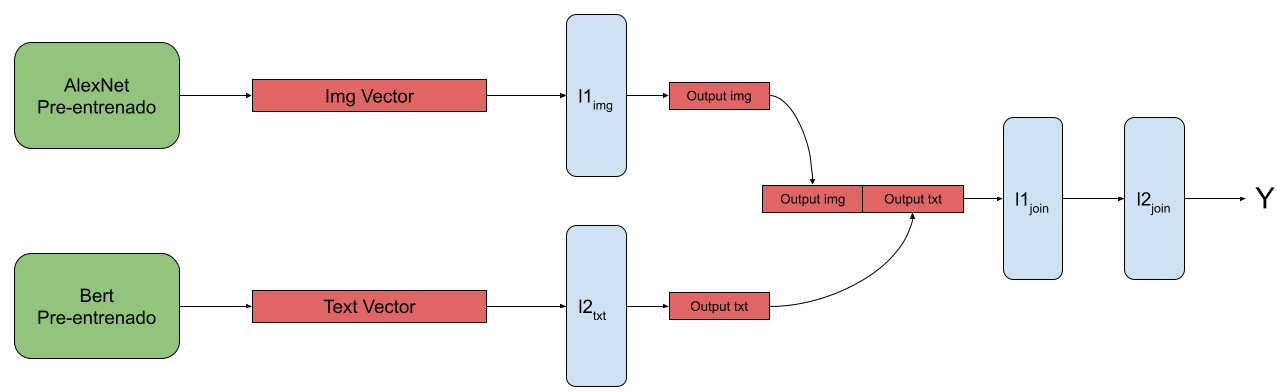

### Baseline

Comparar el funcionamiento de nuestro modelo es fundamental para ver si lo que estamos haciendo funciona bien o mal. En esta ocasión utilizaremos un segundo modelo para poder compararnos. En este solo le entregamos la información de las imágenes a este segundo modelo para realizar la recomendación, esperando que este sea peor que el modelo completo.

In [17]:
class ModelClassImage(torch.nn.Module):
    def __init__(self, pretrained=True, num_classes=117):
        super(ModelClassImage, self).__init__()

        self.l1_img = torch.nn.Linear(4096, 64)
        self.drop = torch.nn.Dropout(0.3)
        self.relu = torch.nn.ReLU(inplace=True)
        self.l2_img = torch.nn.Linear(64, num_classes)

    def forward(self, ids, mask, token_type_ids, img_data, features=False):
        output = self.l1_img(img_data)
        output = self.drop(self.relu(output))
        if features:
            return output
        output = self.l2_img(output)
        return output

## Entrenamiento

Al momento del entrenamiento debemos seleccionar una función de perdida apropiada y un algoritmo de optimización que se comporte bien para este problema.

En este caso al ser un problema de clasificación podemos utilizar la función de pérdida *Cross Entropy*, muy utilizada para este tipo de problemas.

Una alternativa para la función de pérdida podría ser la función *Triplet Loss*, esta busca que el modelo genere representaciones cercanas para elementos de un mismo usuario y genere representaciones más distantes para elementos de usuarios distintos. Un  problema con esa alternativa, es que necesitamos generar triples para el entrenamiento (de ahí su nombre) con elementos de ancla, positivo y negativo para cada iteración en entrenamiento, causando que el proceso sea más complejo, en tiempo y recursos.

Tal como mencionamos en la clase de optimizadores, uno de los algoritmos de optimización en deep learning mas completos y utilizados es Adam, que tiene los beneficios de momentum y la normalización, generando learning rate locales para cada parametros.

Además utilizamos un scheduler en base a la perdida de nuestro set de validación.



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Validating model before training
VAL-Batch 16/16 Loss: 2.3633 Acc: 10.94% 
Epoch N°1
TRAIN-Batch 63/63 Loss: 2.1505 Acc: 23.12% 
VAL-Batch 16/16 Loss: 1.7596 Acc: 51.37% 
Epoch N°2
TRAIN-Batch 63/63 Loss: 1.6804 Acc: 45.54% 
VAL-Batch 16/16 Loss: 1.2710 Acc: 62.60% 
Epoch N°3
TRAIN-Batch 63/63 Loss: 1.3019 Acc: 57.56% 
VAL-Batch 16/16 Loss: 1.0854 Acc: 64.94% 
Epoch N°4
TRAIN-Batch 63/63 Loss: 1.0533 Acc: 66.67% 
VAL-Batch 16/16 Loss: 0.9725 Acc: 67.19% 
Epoch N°5
TRAIN-Batch 63/63 Loss: 0.8772 Acc: 73.44% 
VAL-Batch 16/16 Loss: 0.9106 Acc: 68.26% 


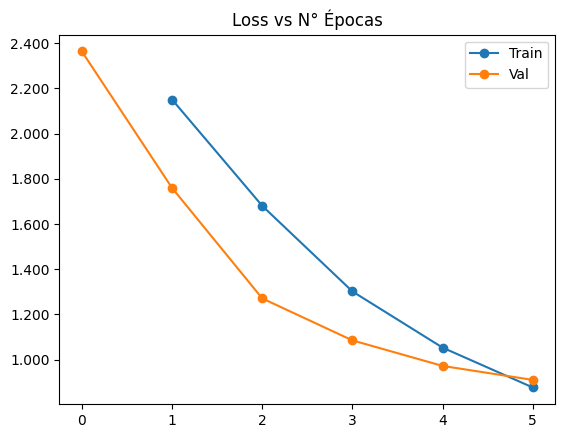

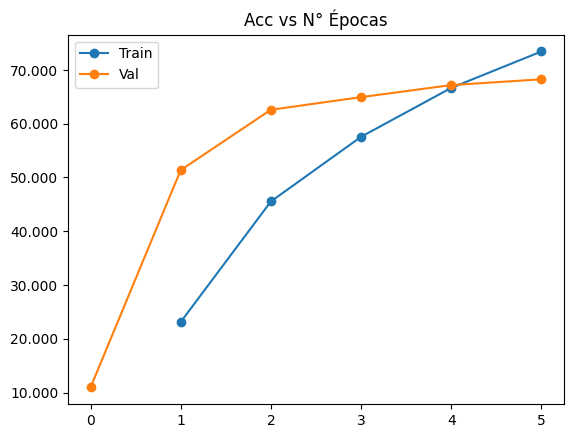

Train Loss: 0.8772 - Train Acc: 73.44%
Val Loss: 0.9106 - Val Acc: 68.26%


In [18]:
from torch import optim
from torch.optim import lr_scheduler
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ModelClass(pretrained=True, num_classes=num_classes)
model.to(device)

criterion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer)

epochs = 5
history = run_training(model, loaders, optimizer, criterion, epochs, scheduler)

print_report(history)

Validating model before training
VAL-Batch 16/16 Loss: 3.0725 Acc: 9.28%  
Epoch N°1
TRAIN-Batch 63/63 Loss: 2.1739 Acc: 23.51% 
VAL-Batch 16/16 Loss: 1.8716 Acc: 38.38% 
Epoch N°2
TRAIN-Batch 63/63 Loss: 1.8571 Acc: 36.51% 
VAL-Batch 16/16 Loss: 1.7158 Acc: 41.02% 
Epoch N°3
TRAIN-Batch 63/63 Loss: 1.6970 Acc: 41.37% 
VAL-Batch 16/16 Loss: 1.6147 Acc: 43.65% 
Epoch N°4
TRAIN-Batch 63/63 Loss: 1.6162 Acc: 43.92% 
VAL-Batch 16/16 Loss: 1.5704 Acc: 44.34% 
Epoch N°5
TRAIN-Batch 63/63 Loss: 1.5588 Acc: 47.02% 
VAL-Batch 16/16 Loss: 1.5351 Acc: 46.39% 


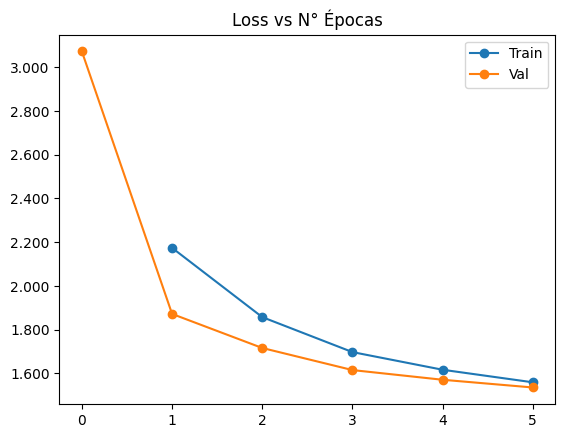

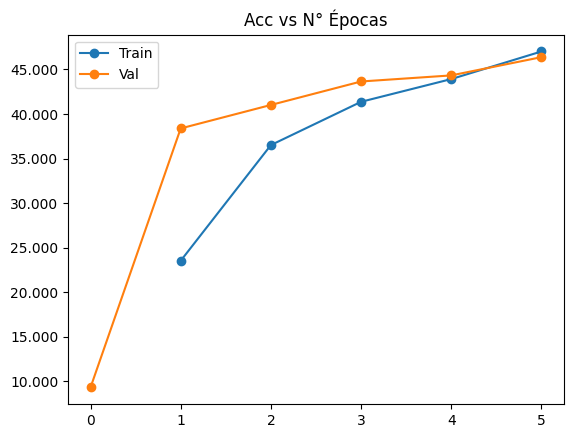

Train Loss: 1.5588 - Train Acc: 47.02%
Val Loss: 1.5351 - Val Acc: 46.39%


In [19]:
from torch import optim
from torch.optim import lr_scheduler
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_img = ModelClassImage(pretrained=True, num_classes=num_classes)
model_img.to(device)

criterion = CrossEntropyLoss()
optimizer = Adam(model_img.parameters(), lr=1e-4) #1e-5
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer)

epochs = 5
history = run_training(model_img, loaders, optimizer, criterion, epochs, scheduler)

print_report(history)

## Actividad 2
1 - Con respecto a los conocimientos adquiridos hasta el momento responda las siguientes preguntas:


- Enumere 2 limitaciones de nuestro modelo. Sugiera una mejora en base a estas limitaciones.

In [20]:
Limitacion_1 = '' #@param {type:"string"}
Limitacion_2 = '' #@param {type:"string"}
Mejora = '' #@param {type:"string"}

- En base a los temas vistos hasta ahora en el diplomado, sugiera una mejora que podría hacerle a este modelo.

In [21]:
Mejora = '' #@param {type:"string"}

- Enumere dos formas que se le ocurran de realizar data augmentation con estos datos.

In [22]:
R_1 = '' #@param {type:"string"}
R_2 = '' #@param {type:"string"}

# Recomendación

Para recomendar contenido a usuarios nos vamos a basar en que usuarios prefieren contenido similar al que ya han interactuado antes. Es decir, imagenes y texto similares a los que a comentado pueden incentivar a generar una nueva interacción.

Una forma que tenemos de verificar si un par imagen-texto es similar a otro es mediante los descriptores que estos tipos de modelos generan para poder realizar la clasificación.



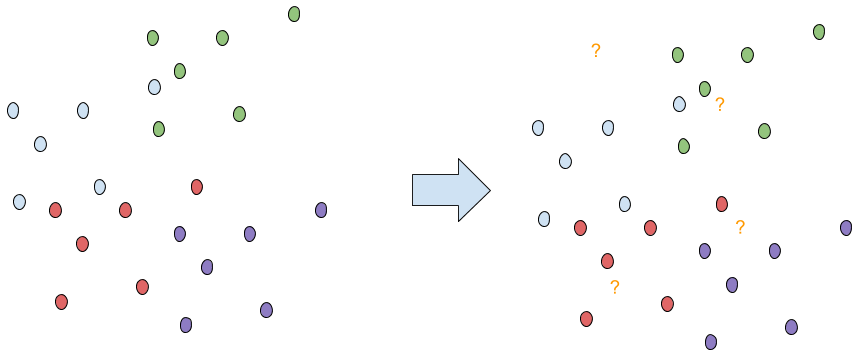

## Obtención de Descriptores

Para obtener una representación que tenga información tanto de la imagen como del texto, utilizamos el parámetro `features` de nuestro modelo. Con esto, en vez de devolvernos las predicciones del modelo, nos entrega un descriptor de nuestro par imagen-texto.

La motivación de esto es la misma que la vista en la clase de finetuning, donde utilizan modelos pre-entrenados para encontrar descriptores de imágenes y luego entrenar un clasificador con estos. La diferencia es que aquí no los vamos a utilizar para entrenar un clasificador sino que lo vamos a utilizar para encontrar distancias entre los diferentes elementos de nuestro dataset.

In [23]:
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
model.to(device)

test_f = np.zeros((len(testset), 32), dtype=np.float32)
model.eval()
for i, b in enumerate(tqdm(testset)):
    ids = b['text_ids'].to(device, dtype=torch.long).unsqueeze(0)
    mask = b['text_mask'].to(device, dtype=torch.long).unsqueeze(0)
    token_type_ids = b['text_token_type_ids'].to(device, dtype=torch.long).unsqueeze(0)
    img = b['img_data'].to(device, dtype=torch.float).unsqueeze(0)
    targets = b['targets'].to(device, dtype=torch.long).unsqueeze(0)

    test_f[i] = model(ids, mask, token_type_ids, img, features=True).detach().numpy()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [24]:
# Hacer lo mismo que en `f` pero con los datos de train

train_f = np.zeros((len(trainset), 32), dtype=np.float16)
model.eval()
for i, b in enumerate(tqdm(trainset)):
    ids = b['text_ids'].to(device, dtype=torch.long).unsqueeze(0)
    mask = b['text_mask'].to(device, dtype=torch.long).unsqueeze(0)
    token_type_ids = b['text_token_type_ids'].to(device, dtype=torch.long).unsqueeze(0)
    img = b['img_data'].to(device, dtype=torch.float).unsqueeze(0)
    targets = b['targets'].to(device, dtype=torch.long).unsqueeze(0)

    train_f[i] = model(ids, mask, token_type_ids, img, features=True).half().detach().numpy()

  0%|          | 0/4000 [00:00<?, ?it/s]

## Encontrar similares

Una vez que tenemos los descriptores tanto del set de entrenamiento como del set de test podemos comenzar a calcular la distancia de los nuevos datos (test) con respecto a los utilizado durante el entrenamiento (train).

La intuicion de esto es que queremos recomendar los nuevos elementos a usuarios con gustos similares, y para esto nos basamos en alguna metrica de distancia entre ambos descriptores. Al encontrar la distancia menor de un elementos con otro sabemos a que usuario recomendarle esta nueva imagen, ya que conocemos el usuario que escribio el comentario en esa imagen en los datos de entrenamiento.

In [25]:
from sklearn.metrics import pairwise_distances
import heapq
import textwrap


def find_similar_images(embedding, query_id=None, metrics=('euclidean',), topk=5):
    assert len(metrics) > 0
    assert topk <= 30 # to avoid requesting too many images
    n = embedding.shape[0]
    if query_id is None:
        query_id = np.random.randint(n)
    results = {}
    # --- show retrieved images for each metric
    for metric in metrics:
        #print('-------- retrieved with metric = %s -----' % metric)
        distances = pairwise_distances(embedding[query_id].reshape(1,-1), embedding, metric=metric)
        heap = []
        for i in range(n):
            if i == query_id:
                continue
            if len(heap) < topk:
                heapq.heappush(heap, (-distances[0][i], i))
            else:
                heapq.heappushpop(heap, (-distances[0][i], i))
        heap.sort(reverse=True)
        results[metric] = tuple(zip(*heap))
        results[metric] = (list(results[metric][1]), [-float(dist) for dist in results[metric][0]])
    return results

def display_item_text(dataset, item_ids):
  """Displays the text for a list of item IDs with improved formatting and wrapping."""
  for i, item_id in enumerate(item_ids):
    print((f"----- Recommended Item {i+1} " + "-----"*60)[:60])
    print()
    wrapped_text = textwrap.fill(dataset.txt_data[item_id], width=60) # Wrap text at 80 characters
    print(wrapped_text)
    print()
    print("-" * 60) # Add a separator line


In [26]:
query_id = 2
find_similar_images(test_f, metrics=('cosine','euclidean'), query_id=query_id, topk=10)

{'cosine': ([48, 59, 29, 19, 12, 65, 93, 3, 63, 97],
  [0.009655773639678955,
   0.010363399982452393,
   0.012980341911315918,
   0.013662576675415039,
   0.014034807682037354,
   0.0158231258392334,
   0.016454994678497314,
   0.016454994678497314,
   0.017199158668518066,
   0.018291115760803223]),
 'euclidean': ([48, 19, 63, 28, 83, 27, 12, 8, 97, 29],
  [2.729814052581787,
   3.1111836433410645,
   3.4022715091705322,
   3.570603609085083,
   3.5892081260681152,
   3.7698349952697754,
   3.8000779151916504,
   3.8032047748565674,
   3.835481882095337,
   3.846243381500244])}

## Recomendación

Tal como se menciono en la sección anterior, con las distancias entre los vectores podemos recomendar nuevo contenido a un usuario, considerando las distancias minimas entre estos.

In [27]:
targets = np.array(testset.targets)
n_targets = len(set(targets))

In [28]:
# Creo diccionarios con user_id => feats (los features concatenados de todos los items del usuario en train)
# y lo transformo a un np.array (user_repr)
from collections import defaultdict

user_dict = {}
for user_id, features in zip(trainset.targets, train_f):
    if not user_id in user_dict:
        user_dict[user_id] = []
    user_dict[user_id].append(features)

for user_id in user_dict:
    user_dict[user_id] = np.array(user_dict[user_id])

user_repr = np.array([user_dict[user_id] for user_id in range(n_targets)])

In [29]:
# Calculo los scores para cada imágen en test con respecto a un usuario
metric = 'cosine'

n_users, n_images, _ = user_repr.shape
user_repr = user_repr.reshape(-1, 32)
dists = pairwise_distances(user_repr, test_f, metric=metric)
dists = dists.reshape(n_users, n_images, -1)
scores = dists.min(axis=1)

print(scores.shape)

(10, 1000)


In [30]:
# Lista de recomendación
k = 10
recommendation_list = np.argpartition(scores, k)
recommendation_list = recommendation_list[:,:k]

En esta lista se muestra el id de los elementos de nuestro base de datos (imagen-texto) que le podria interesar a 10 usuarios diferentes, en base a las menores distancias de los elementos que conocemos del usuario con cada uno de los nuevos elementos que nos llegaron.

In [31]:
recommendation_list

array([[ 99,  25,  15,  39,  44,   6,  51,  14,  16,   1],
       [162, 176, 168, 199, 196, 159, 122, 124, 932, 912],
       [253, 257, 206, 254, 484, 255, 425, 446, 229, 225],
       [392, 360, 322, 856, 371, 343, 894, 346, 461, 318],
       [488, 480, 482, 277, 261, 451, 478, 437, 236, 409],
       [590, 517, 506, 554, 530, 513, 576, 553, 539, 538],
       [603, 686, 605, 637, 625, 679, 742, 699, 640, 725],
       [767, 709, 285, 707, 765, 225,  78, 718,  60, 726],
       [891, 855, 805, 810, 837, 848, 815, 880, 809, 878],
       [977, 912, 933, 932, 942, 938, 971, 929, 934, 910]])

In [32]:
user_id_to_display = 0

# Muestra el texto de los artículos recomendados para el usuario seleccionado.
recommended_item_ids = recommendation_list[user_id_to_display]
query_id = recommended_item_ids[user_id_to_display] # Using the first recommended item as a placeholder query

# Muestra el texto del elemento consultado.
print(f"Query item text for user {user_id_to_display}:")
print()
wrapped_query_text = textwrap.fill(testset.txt_data[query_id], width=60)
print(wrapped_query_text)
print()

print(f"\nRecommended items for user {user_id_to_display}:\n")
display_item_text(testset, recommended_item_ids)

Query item text for user 0:

this sterling silver cuff bracelet showcases a gorgeous vine
motif openwork design polished and oxidized silver add depth
and interest to the pattern this is an eye catching
accessory that s easy to wear and will complement any outfit


Recommended items for user 0:

----- Recommended Item 1 -----------------------------------

this sterling silver cuff bracelet showcases a gorgeous vine
motif openwork design polished and oxidized silver add depth
and interest to the pattern this is an eye catching
accessory that s easy to wear and will complement any outfit

------------------------------------------------------------
----- Recommended Item 2 -----------------------------------

perspective by docker soft burnished upper leathers
lightweight latex rubber outsole for extreme flexibility and
comfort full length eva cushioned footbed with gel heel pad
updated tpr outsole design with comfort sure grip bottom

---------------------------------------------------

## Métricas de Comparación

Tal como vimos en clases, existen varias métricas que se pueden utilizar para comprobar el correcto funcionamiento de nuestro modelo de recomendación.

Las primeras métricas son *Precision* y *Recall*, que nos entregan la cantidad de datos correctos recuperamos y estamos recuperando, respectivamente. La siguiente figura nos puede ayudar a entender estos conceptos.

<figure>
<center>
<img src='https://upload.wikimedia.org/wikipedia/commons/2/26/Precisionrecall.svg' height="500" />
<figcaption>Cálculo de precision y recall.</figcaption>
</center>

</figure>

La *Precision* nos dice la cantidad de elementos correctos que recuperamos en nuestro set, es decir, de los elementos que recomendamos al usuario, cuantos de estos efectivamente pueden gustarle a la persona.

> $Precision = \frac{True Positive}{True Positive + False Positive} $

Por otro lado, el *Recall* nos indica la cantidad de elementos relevantes que le estamos mostrando al usuario del total de elementos relevantes que sabemos le pueden gustar. Es decir, del total de elementos relevantes para el usuario que tenemos en nuestra base de datos, cuantos de estos los estamos mostrando en nuestra recomendación.

> $Recall = \frac{True Positive}{True Positive + False Negative} $

Una métrica particular para sistemas recomendadores es Normalized Discounted Cumulative Gain (nDCG), que busca entregar una metrica con respecto al ránking que le estamos entregando. La intuición es que los elementos mas relevantes debería aparecer primero en nuestro ránking para ir disminuyendo en relevancia.

> $nDCG_p = \frac{\sum_{i=1}^p\frac{2^{rel_i}-1}{log_2(i+1)}}{\sum_{i=1}^{REL_p}\frac{2^{rel_i}-1}{log_2(i+1)}} = \frac{DCG_p}{IDCG_p}$

En nuestro caso, todos los elementos que queremos recomendarle al usuario tienen igual relevancia (1) y los otros tienen relevancia cero (0).

In [33]:
from sklearn.metrics import ndcg_score

def ndcg(scores, targets, k):
    relevance = np.zeros((targets.size, targets.max() + 1))
    relevance[np.arange(targets.size), targets] = 1
    relevance = relevance.T

    return ndcg_score(relevance, scores, k=k)

def pr_at_k(scores, targets, k):
    recs = np.argpartition(scores, k)
    recs = recs[:,:k]
    n_targets = len(set(targets))
    rels = np.array([np.where(targets == user_id)[0] for user_id in range(n_targets)])

    precision = []
    recall = []
    for user_id, (recommended, relevants) in enumerate(zip(recs, rels)):
        recommended = recommended[:k]
        recommended = set(recommended)
        relevants = set(relevants)
        p = len(recommended & relevants) / len(recommended)
        r = len(recommended & relevants) / len(relevants)
        precision.append(p)
        recall.append(r)

    return np.mean(p), np.mean(r) # P@k, R@k

In [34]:
pr, rec = pr_at_k(scores, targets, k=400)
obtained_ndcg = ndcg(scores, targets, k=400)
print(f'P={pr}')
print(f'R={rec}')
print(f'nDCG={obtained_ndcg}')

P=0.25
R=1.0
nDCG=0.040899100238895744


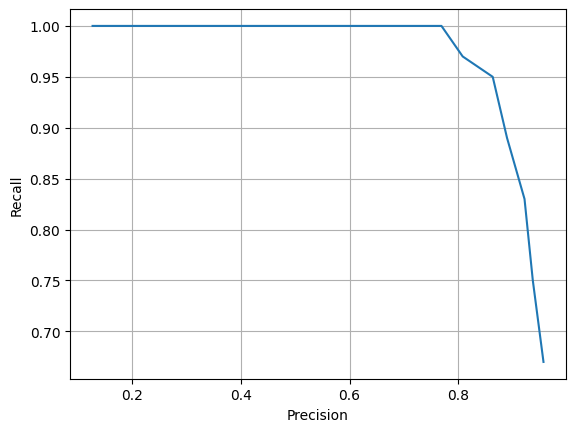

In [35]:
pr_all = []
rec_all = []
ndcg_all = []
for i in range(70, 800, 10):
    pr, rec = pr_at_k(scores, targets, k=i)
    pr_all.append(pr)
    rec_all.append(rec)
    o_ndcg = ndcg(scores, targets, k=i)
    ndcg_all.append(o_ndcg)

fig, ax = plt.subplots()
ax.plot(pr_all, rec_all)

ax.set(xlabel='Precision', ylabel='Recall')
ax.grid()

plt.show()

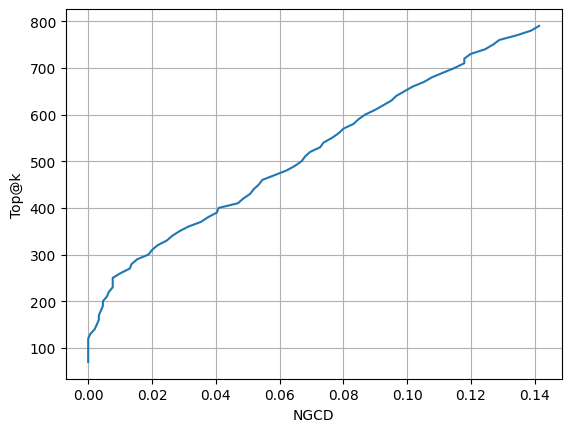

In [36]:
fig, ax = plt.subplots()
ax.plot(ndcg_all, list(range(70, 800, 10)))

ax.set(xlabel='NGCD', ylabel='Top@k')
ax.grid()

plt.show()

## Actividad 3


1. A parte del rendimiento del sistema recomendador, ¿qué otros aspectos le parece importante medir en un sistema como el desarrollado? De uno o dos y brevemente describa (1-3 frases) por qué es relevante.

In [37]:
R = "" #@param {type:"string"}
Por_que = "" #@param {type:"string"}


2. ¿Qué métrica, diferentes de las mencionadas en clases, le podría servir para medir estos aspectos en su modelo?
Enumere una o dos métricas.

In [38]:
R_1 = "" #@param {type:"string"}
R_2 = "" #@param {type:"string"}
